# Liquid vs less-liquid book split

**Deck:** Rindi et al. MMCV #3 — liquid vs less-liquid books flip signs for MQ under large absolute / relative tick changes (pp. 20–29).

**Crypto map:** UTC-day terciles by `quoted_spread_bps` (low spread = liquid). Interaction with relative tick $\tau/\mathrm{mid}$. Placebo = hours with material mid move but flat relative tick. Make/take proxy = $\rho(\Delta\mathrm{rel\_tick},\mathrm{undercut\_rate})$.

**Slice:** ETH · HL + Deribit + Kraken. Kraken `trade_synth` TOB labeled and excluded from make/take & placebo native tests.

Artifacts: `out/liq_book_split/` · regenerate via `chapters/liq_book_split/_run_local.py`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import Image, display, Markdown

OUT = Path('../../out/liq_book_split').resolve()
FIGS = OUT / 'figs'
summary = json.loads((OUT / 'summary.json').read_text())
days = pd.DataFrame(summary['day_rows'])
print('symbol', summary['symbol'], 'days', summary['days'])
print('n_day', summary['n_day_rows'], 'n_hour', summary['n_hour_rows'], 'synth_days', summary['n_synth_days'])
print('het', json.dumps(summary['het'], indent=2))
print('make_take', json.dumps(summary['make_take'], indent=2))
print('placebo', summary['placebo'])
print('note:', summary.get('note_kraken'))
display(days[['venue','day','book_liq','quoted_spread_bps','rel_tick_bps','undercut_rate','is_synth','tob_source']].sort_values(['day','venue']))

symbol ETH days ['2026-09-26', '2026-09-27', '2026-09-30']
n_day 9 n_hour 150 synth_days 3
het {
  "liquid": {
    "n": 3,
    "rho_rel_tick_spread": 1.0,
    "rho_rel_tick_depth": -0.5,
    "mean_spread_bps": 0.3723647605986915,
    "mean_rel_tick": 3.723275842684464e-05
  },
  "mid": {
    "n": 3,
    "rho_rel_tick_spread": -0.5,
    "rho_rel_tick_depth": NaN,
    "mean_spread_bps": 1.500000000000927,
    "mean_rel_tick": 3.722785652296148e-05
  },
  "less_liquid": {
    "n": 3,
    "rho_rel_tick_spread": -0.5,
    "rho_rel_tick_depth": 1.0,
    "mean_spread_bps": 3.0415562798983817,
    "mean_rel_tick": 1.8595721440574118e-05
  }
}
make_take {
  "liquid": {
    "n": 52,
    "rho_drel_undercut": 0.0134892854093742,
    "hypothesis": "expect rho(\u0394rel_tick, undercut)<0 on liquid (rel\u2193 \u2192 undercut\u2191)"
  },
  "less_liquid": {
    "n": 36,
    "rho_drel_undercut": -0.05148005148005148,
    "hypothesis": "expect weaker / flipped undercut channel on thin"
  },
  "mid": {
 

,venue,day,book_liq,quoted_spread_bps,rel_tick_bps,undercut_rate,is_synth,tob_source
1,deribit,2026-09-26,less_liquid,3.725297,0.185951,0.049432,False,warehouse:l2_tob/s3_cache
0,hyperliquid,2026-09-26,liquid,0.371948,0.371948,0.041722,False,warehouse:l2_rebuild/s3_cache
2,kraken,2026-09-26,mid,1.500000,0.371982,0.357343,True,warehouse:trade_synth/s3_cache
4,deribit,2026-09-27,less_liquid,3.537747,0.185813,0.054943,False,warehouse:l2_tob/s3_cache
3,hyperliquid,2026-09-27,liquid,0.371713,0.371713,0.061175,False,warehouse:l2_rebuild/s3_cache
5,kraken,2026-09-27,mid,1.500000,0.371789,0.279537,True,warehouse:trade_synth/s3_cache
7,deribit,2026-09-30,less_liquid,1.861625,0.186107,0.066398,False,warehouse:l2_tob/s3_cache
6,hyperliquid,2026-09-30,liquid,0.373434,0.373322,0.043678,False,collector
8,kraken,2026-09-30,mid,1.500000,0.373065,0.236981,True,warehouse:trade_synth/s3_cache


## Pass 1 — tercile × relative tick

**ID caveat:** on this 3-day ETH slice, terciles align with venues (HL→liquid, Kraken synth→mid, Deribit→less_liquid). Treat $\rho$ as descriptive venue-confounded heterogeneity until coin×day panel widens.

### `fig_tercile_rel_tick_spread.png`

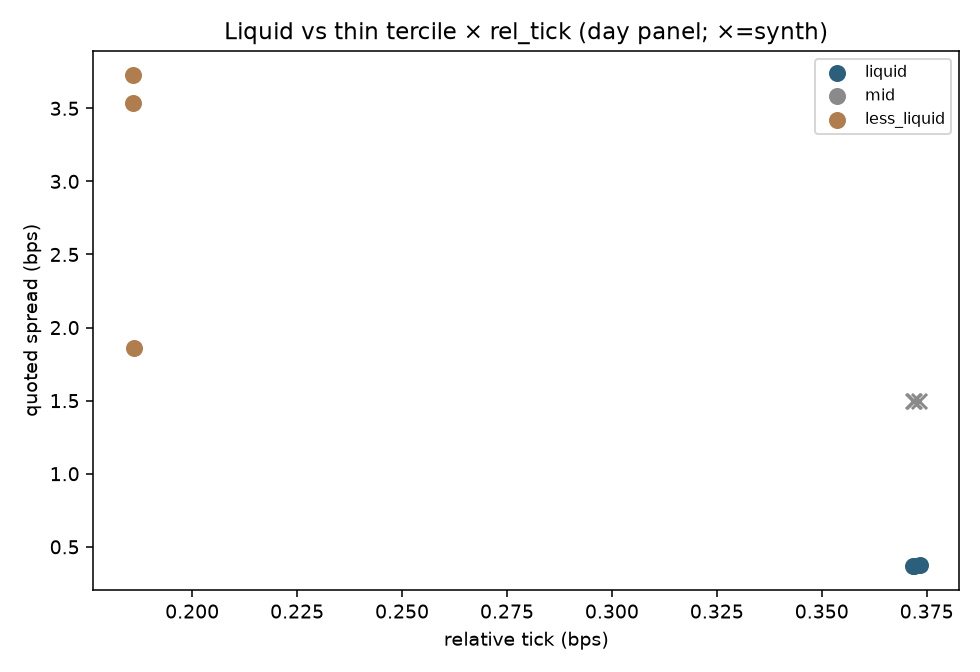

### `fig_het_rho_bars.png`

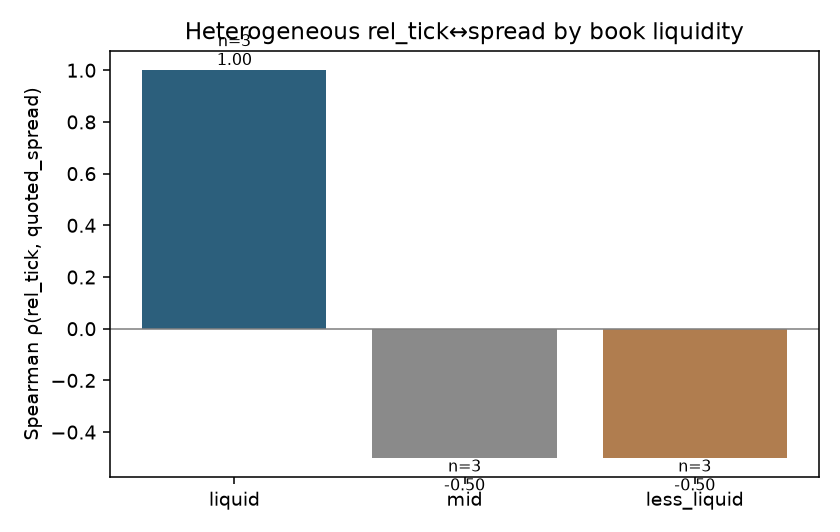

### `fig_hour_interaction.png`

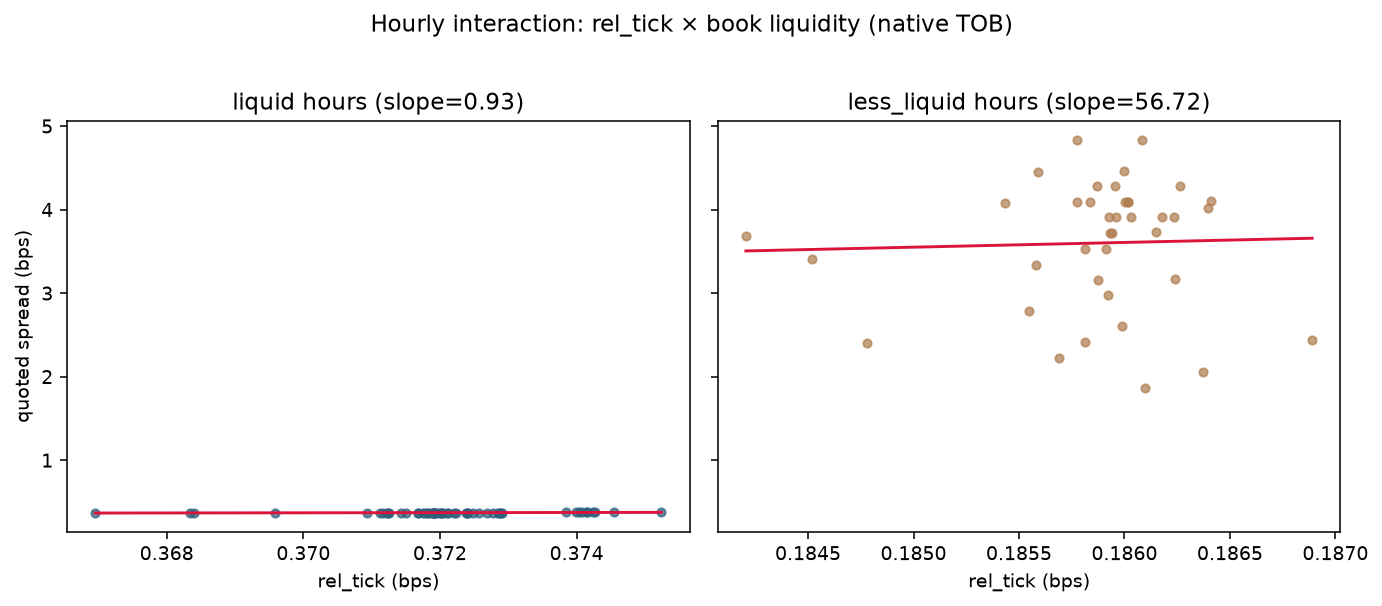

### `fig_depth_vs_rel_tick.png`

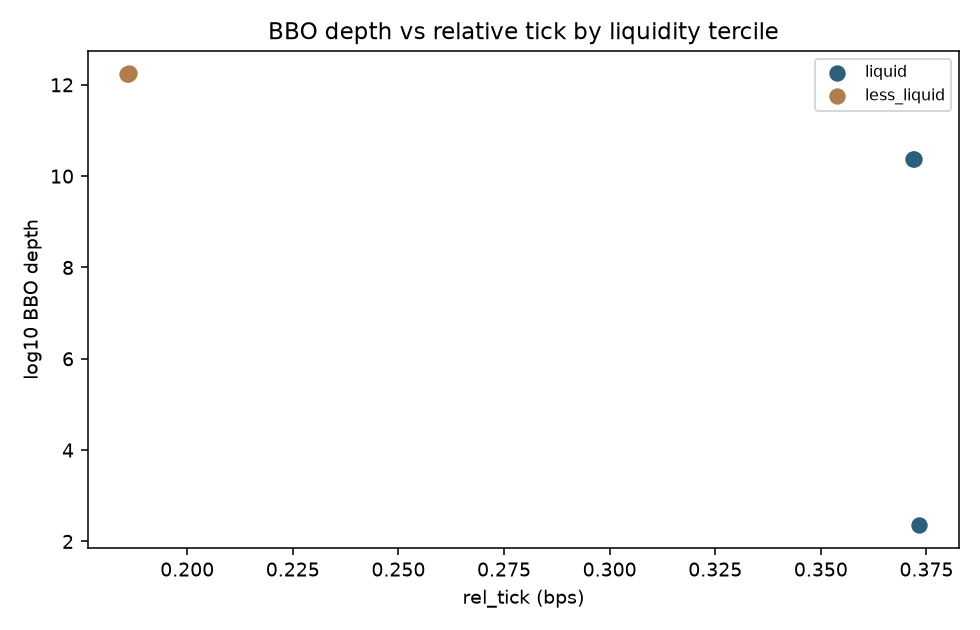

In [2]:
for name in ['fig_tercile_rel_tick_spread.png', 'fig_het_rho_bars.png', 'fig_hour_interaction.png', 'fig_depth_vs_rel_tick.png']:
    display(Markdown(f'### `{name}`'))
    display(Image(filename=str(FIGS / name)))

## Pass 2 — placebo mid moves & make/take

**Placebo rule:** hour with mid range ≥ 5 bps and $\mathrm{rel\_tick}$ range / level < 2% (τ fixed ⇒ relative tick almost flat).
If the rel-tick channel is the story, $\Delta$ quoted spread on placebo hours should be ≈ 0.

**Make/take:** liquid books should undercut when relative tick *falls* → expect $\rho(\Delta\mathrm{rel\_tick},\mathrm{undercut}) < 0$.

placebo hours flagged: 55
mean Δqs on placebo: 0.000041 bps | mean |Δqs|: 0.000696 bps
liquid: n=52 rho(d_rel, undercut)=0.0134892854093742
less_liquid: n=36 rho(d_rel, undercut)=-0.05148005148005148
mid: n=0 rho(d_rel, undercut)=nan


### `fig_placebo_mid_move.png`

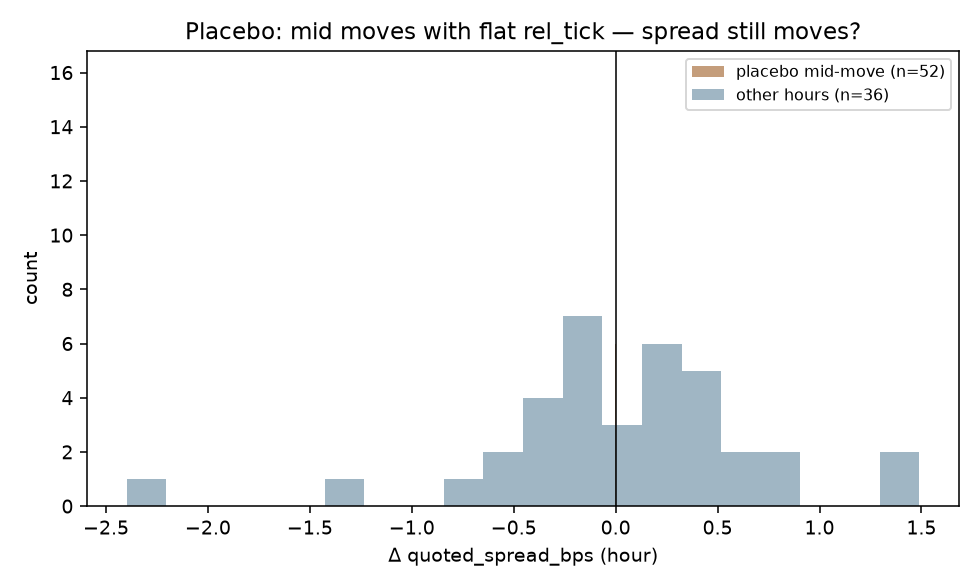

### `fig_make_take_rho.png`

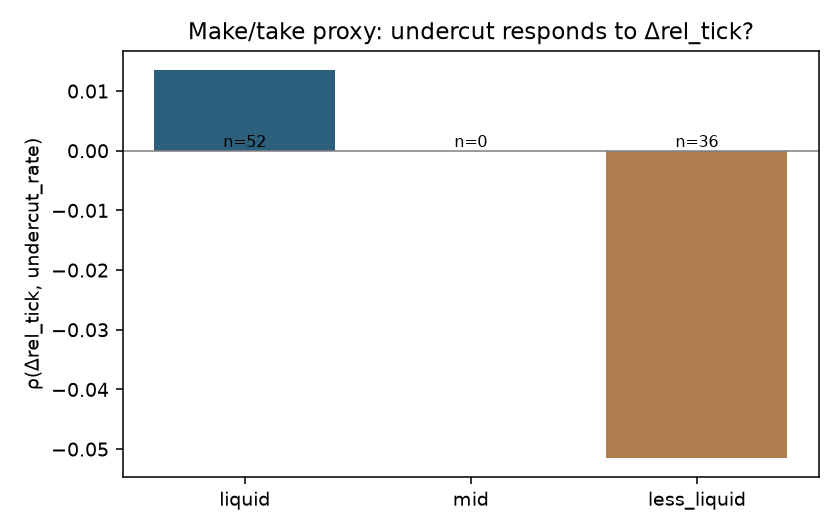

In [3]:
pl = summary['placebo']
print(f"placebo hours flagged: {pl['n_hours_flagged']}")
print(f"mean Δqs on placebo: {pl['mean_dqs_bps']:.6f} bps | mean |Δqs|: {pl['mean_abs_dqs_bps']:.6f} bps")
mt = summary['make_take']
for book in ('liquid', 'less_liquid', 'mid'):
    r = mt.get(book, {})
    print(f"{book}: n={r.get('n')} rho(d_rel, undercut)={r.get('rho_drel_undercut')}")
for name in ['fig_placebo_mid_move.png', 'fig_make_take_rho.png']:
    display(Markdown(f'### `{name}`'))
    display(Image(filename=str(FIGS / name)))

## Signal board / gate

| Candidate | Tentative | Why |
|-----------|-----------|-----|
| `liq.book_tercile_het` | **Hold** | n=3/tercile; venue-confounded; ρ liquid=+1 / thin=−0.5 is fragile |
| `liq.placebo_flat_rel_tick` | **Hold → leaning useful falsifier** | 55 placebo hours; mean \|Δqs\| ≈ 0 — consistent with "no MQ move when rel_tick flat", but need bootstrap CI |
| `exec.make_take_undercut` | **Hold / weak Kill risk** | liquid $\rho(\Delta\mathrm{rel},\mathrm{undercut})\approx 0.01$ — does **not** support deck undercutting channel on this slice |

**Gate recommendation:** **Hold** `liq.book_tercile_het`; do not Promote make/take. Placebo is the strongest Pass-2 object — Promote only after block-bootstrap CI excludes large Δqs and BTC replication.

In [4]:
# Venue confound check: book_liq vs venue
print(pd.crosstab(days['venue'], days['book_liq']))
print('figs on disk:', sorted(p.name for p in FIGS.glob('fig_*.png')))

book_liq     less_liquid  liquid  mid
venue                                
deribit                3       0    0
hyperliquid            0       3    0
kraken                 0       0    3
figs on disk: ['fig_depth_vs_rel_tick.png', 'fig_het_rho_bars.png', 'fig_hour_interaction.png', 'fig_make_take_rho.png', 'fig_placebo_mid_move.png', 'fig_tercile_rel_tick_spread.png']
